In [1]:
from utils import*

In [ ]:
# linear regression
from sklearn.linear_model import LinearRegression

# static plot
from mpl_toolkits.mplot3d import Axes3D

# dynamic plot
import plotly.graph_objects as go
import panel as pn
pn.extension('plotly')

In [2]:
# NONE 1000 runs

# df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/folds_folditer_NONE.csv', index_col=0)
# df_cpds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/cpds_folditer_NONE.csv', index_col=0)
# df_rns_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/rns_folditer_NONE.csv', index_col=0)
# df_rules_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/rules_folditer_NONE.csv', index_col=0)

In [3]:
# preATP 1000 runs

df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/folds_folditer_preATP.csv', index_col=0)
df_cpds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/cpds_folditer_preATP.csv', index_col=0)
df_rns_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rns_folditer_preATP.csv', index_col=0)
df_rules_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rules_folditer_preATP.csv', index_col=0)

In [4]:
x2foMean = {}
x2foStd = {}
for x in df_folds_folditer.index:
    if x not in ['fold_independent', 'spontaneous']:
        x2foMean[x] = np.mean(df_folds_folditer.loc[x])
        x2foStd[x] = np.std(df_folds_folditer.loc[x])

print(len(x2foMean))
print(len(x2foStd))

396
396


In [5]:
# remove reactions that do not appear in our runs from rn2rules
rn2rules_run = {rn:rules for rn, rules in rn2rules.items() if rn in df_rns_folditer.index}
len(rn2rules_run)

5733

In [6]:
x2rulesNum = csv2dict('../data/assets/xgroup2/xgroup2rulesNum.csv')
x2rulesNum_run = {}
for rn, rules in rn2rules_run.items():
    for rule in rules:
        for x in rule:
            if x not in x2rulesNum_run.keys():
                x2rulesNum_run[x] = 1
            else:
                x2rulesNum_run[x] += 1
x2rulesNum_run.pop('spontaneous')
print(len(x2rulesNum_run))

396


# 1. Define 'evolvability score'

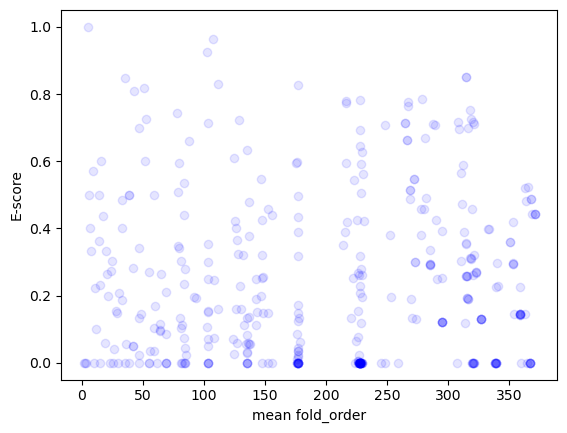

In [7]:
x2escore_run = {}
for fold in x2foMean:
    Xnum = x2rulesNum_run[fold]
    Xfo = x2foMean[fold]

    older = []
    for x, fo in x2foMean.items():
        if fo < Xfo:
            older.append(x)

    fewer = []
    for x in older:
        if x2rulesNum_run[x] < Xnum:
            fewer.append(x)

    if len(older) != 0:
        escore = len(fewer)/len(older)
    else:
        escore = 0
    x2escore_run[fold] = escore
    
scatter(x2foMean, x2escore_run, 'mean fold_order', 'E-score')

# 2. #rules for evolvability: 3D regression

In [8]:
x2rulesNum = csv2dict('../data/assets/xgroup2/xgroup2rulesNum.csv')
x2rulesNum_run = {}
for rn, rules in rn2rules_run.items():
    for rule in rules:
        for x in rule:
            if x not in x2rulesNum_run.keys():
                x2rulesNum_run[x] = 1
            else:
                x2rulesNum_run[x] += 1
x2rulesNum_run.pop('spontaneous')
print(len(x2rulesNum_run))

396


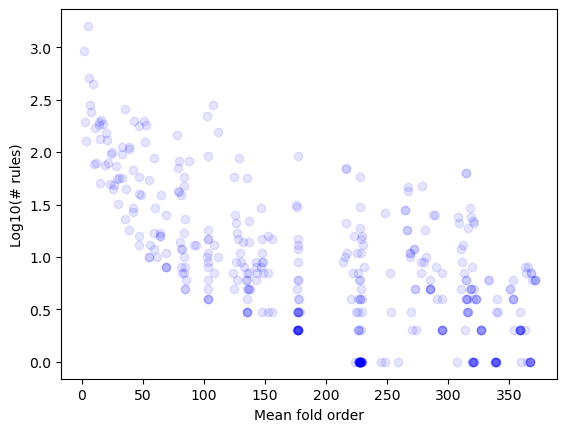

In [9]:
ylog(x2foMean, x2rulesNum_run, 'Mean fold order', 'Log10(# rules)') 
# loglog(x2foMean, x2rulesNum_run, 'Log(Mean fold order)', 'Log10(# rules)') 

In [116]:
def scatterColor(dict1, dict2, dict3, x_axis = 'x-axis', y_axis = 'y-axis', z_axis = 'z-axis', ylog=False):
    xgroups = list(dict3.keys())
    x_values = [dict1[xgroup] for xgroup in xgroups]
    y_values = [dict2[xgroup] for xgroup in xgroups]
    z_values = [dict3[xgroup] for xgroup in xgroups]

    if ylog:
        y_values = np.log10(y_values)
    
    plt.scatter(x_values, y_values, c=z_values, cmap='bwr', edgecolor='k', alpha=0.7)
    # plt.plot([0, max(y_values)], [0, max(x_values)], color='black', linestyle='--')
    plt.colorbar(label=z_axis)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig(f'scatterColor_{x_axis}_{y_axis}_{z_axis}.png')
    plt.show()

In [11]:
x2ds_run = {x: ds for x,ds in x2ds.items() if x in x2rulesNum_run.keys()}
len(x2ds_run)

396

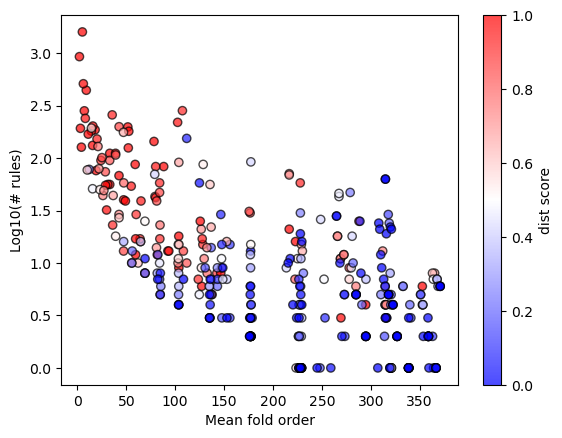

In [117]:
scatterColor(x2foMean, x2rulesNum_run, x2ds_run, 'Mean fold order', 'Log10(# rules)', 'dist score', ylog=True) 

In [13]:
# bokeh plot: 
d1 = x2foMean
d2 = x2rulesNum_run

output_file("scatter.html")
p = figure(width=800, height=800, title="evol.")

# Add annotations
valid_keys, data1, data2 = todata(d1, d2)
data2 = np.log10(data2)

source = {'x': data1, 'y': data2, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in valid_keys]}
p.scatter('x', 'y', source=source, size=10, alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("fold", "@label")]
p.add_tools(hover)

# Customize plot
# p.xaxis.axis_label = 'mean fold_order'
# p.yaxis.axis_label = 'std fold_order'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

## 3D regression

In [14]:
x2rulesNum_runLog = {k:np.log10(v) for k,v in x2rulesNum_run.items()}

In [157]:
# 3D regression with x2rulesNum_run, x2foMean, x2ds

feature1 = x2foMean  # feature (independent)
feature2 = x2ds_run  # feature (independent)
# target = x2rulesNum_run  # target (dependent);
target = {k:np.log10(v) for k,v in x2rulesNum_run.items()}  # target (dependent); log10

# Ensure consistent ordering of keys
keys = list(target.keys())

# Extract feature and target values in the same order
X = np.array([[feature1[k], feature2[k]] for k in keys])  # 2D array of features
y = np.array([target[k] for k in keys])  # Target variable

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Print the coefficients and intercept
print("Coefficients (slopes):", model.coef_)
print("Intercept:", model.intercept_)

Coefficients (slopes): [-0.00286582  0.60069339]
Intercept: 1.214618018083234


In [40]:
# # alternatively, build a model using only folds with fold_order > 100

# feature1 = {k:v for k,v in x2foMean.items() if v > 100}  # feature (independent)
# feature2 = {k:v for k,v in x2ds_run.items() if k in feature1} # feature (independent)
# target = {k:v for k,v in x2rulesNum_run.items() if k in feature1} # target (dependent)

# # Ensure consistent ordering of keys
# keys = list(target.keys())

# # Extract feature and target values in the same order
# X = np.array([[feature1[k], feature2[k]] for k in keys])  # 2D array of features
# y = np.array([target[k] for k in keys])  # Target variable

# # Create and fit the linear regression model
# model = LinearRegression()
# model.fit(X, y)

# # Print the coefficients and intercept
# print("Coefficients (slopes):", model.coef_)
# print("Intercept:", model.intercept_)

Coefficients (slopes): [-0.05955392 14.06202705]
Intercept: 21.043747304568967


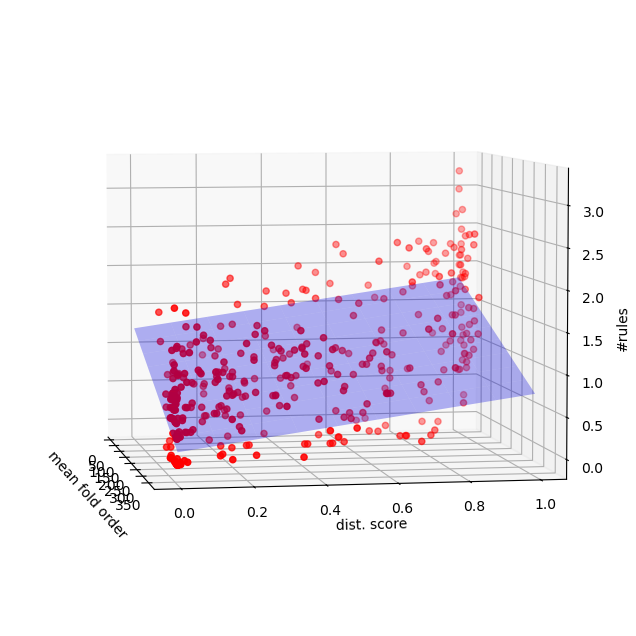

In [158]:
# static plot

# Coefficients and intercept
coef = model.coef_
intercept = model.intercept_

# Generate points on the regression plane for visualization
feature1_vals = np.linspace(min(feature1.values()), max(feature1.values()), 10)
feature2_vals = np.linspace(min(feature2.values()), max(feature2.values()), 10)
feature1_vals, feature2_vals = np.meshgrid(feature1_vals, feature2_vals)
target_vals = coef[0] * feature1_vals + coef[1] * feature2_vals + intercept

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the original data points
ax.scatter(list(feature1.values()), list(feature2.values()), list(target.values()), color='red', label='Data Points')

# Plot the regression plane
ax.plot_surface(feature1_vals, feature2_vals, target_vals, color='blue', alpha=0.3)

# Set labels
ax.set_xlabel('mean fold order')
ax.set_ylabel('dist. score')
ax.set_zlabel('#rules')

# Adjust the 3D perspective (e.g., 30° elevation, 60° azimuth)
ax.view_init(elev=5, azim=350)

# Show plot
plt.show()

In [159]:
# dynamic plot

# Generate points on the regression plane for visualization
feature1_vals = np.linspace(min(feature1.values()), max(feature1.values()), 10)
feature2_vals = np.linspace(min(feature2.values()), max(feature2.values()), 10)
feature1_vals, feature2_vals = np.meshgrid(feature1_vals, feature2_vals)
target_vals = model.coef_[0] * feature1_vals + model.coef_[1] * feature2_vals + model.intercept_

# Create a 3D scatter plot with the regression plane
fig = go.Figure()

for name in feature1.keys():
    fig.add_trace(go.Scatter3d(
        x=[feature1[name]], 
        y=[feature2[name]], 
        z=[target[name]], 
        mode='markers',
        marker=dict(size=2, color='red'),
        name=name  # Unique name for each data point
    ))

# Surface plot for the regression plane
fig.add_trace(go.Surface(
    x=feature1_vals, 
    y=feature2_vals, 
    z=target_vals, 
    colorscale='Viridis', 
    opacity=0.6,
    name='Regression Plane'
))

# Update the layout for better visualization
fig.update_layout(
    scene=dict(
        xaxis_title='mean fold order',
        yaxis_title='dist. score',
        zaxis_title='#rules',
        camera=dict(
            eye=dict(x=1.75, y=1.75, z=1.75)  # Set the viewing angle
        )
    )
)

# Display the interactive plot using Panel
bokeh_layout = pn.pane.Plotly(fig)
bokeh_layout.servable()  # plot within jupyter notebook
# bokeh_layout.show()  # opens new window

Plotly(Figure)

In [43]:
# # Get the predicted value & residual for an X-group
# x = '3323'

# p = model.predict(np.array([[feature1[x], feature2[x]]]))
# r = target[x] - p
# print(f"Predicted value for {x}: {p}")
# print(f"Residual for {x}: {r}")

Predicted value for 3323: [2.31627223]
Residual for 3323: [60.68372777]


In [202]:
# Define the outliers (mean & std of residuals)

# Calculate predicted values
y_pred = model.predict(X)

# Calculate residuals (actual - predicted)
residuals = y - y_pred

# Calculate the mean and standard deviation of the residuals
mean_residual = np.mean(residuals)
std_residual = np.std(residuals)

# Define a threshold for outliers (e.g., residuals greater than X standard deviations from the mean)
threshold = 1.5 * std_residual

# Identify index of outliers
outliers = np.where(np.abs(residuals - mean_residual) > threshold)[0]

# Print the outliers
keys = list(target.keys()) 
outlier_keys = [keys[i] for i in outliers]  # convert index to key
print("Outlier keys:", outlier_keys)
print("Outlier residuals:", residuals[outliers])

Outlier keys: ['2002', '2003', '304', '2007', '253', '7584', '4011', '149', '3321', '3323', '222', '109', '5067', '244', '4052', '4033', '12', '141', '6094', '243', '7514', '107', '7540', '305', '377', '867', '650', '284', '4111', '319', '66', '235', '4294', '2496', '3651', '632', '132', '1074', '179', '378', '920', '3322', '3294', '875', '146', '262', '842', '309']
Outlier residuals: [ 1.15703101  1.40123327  0.85688452  0.91030422 -0.88746333  0.83665818
  0.82340783  1.25151246  1.4870148   1.48607972  0.7716574   0.73597922
 -1.08482152  0.83761176  0.90356527  0.93191383  0.78561301  0.99523233
  0.88533554  1.00492538  0.77302981  0.76153548 -0.76742856 -0.88537029
 -0.98243441  0.73610443 -0.99698695 -1.13942273 -0.76482354 -1.0261619
  1.07046999 -0.86604746  0.95489093 -0.78777505 -0.79875801 -1.12643278
  1.02961184  0.96909016  1.10895129  0.85623254  0.99172804  0.96964707
  1.02774112 -0.90518259  1.04631523  0.99147065 -0.89602967 -1.14880498]


In [203]:
len(target), len(outliers)

(396, 48)

In [162]:
# Define the outliers (absolute residuals)

# Calculate absolute residuals
# abs_residuals = np.abs(residuals)

# Set a threshold for absolute residuals (you can adjust this value based on your data)
# threshold = np.percentile(abs_residuals, 80)  # Top 5% of errors are considered outliers

# Identify outliers
# outliers2 = np.where((abs_residuals > threshold) & (residuals > 0))[0]
outliers2 = np.where(residuals > 0)[0]

# Get the outlier keys
keys = list(target.keys()) 
outlier_keys2 = [keys[i] for i in outliers2]

print("Outlier keys:", outlier_keys2)
print("Outlier residuals:", residuals[outliers2])

Outlier keys: ['2002', '2003', '298', '2484', '304', '129', '5', '279', '7524', '2486', '11', '1', '7579', '2007', '2006', '206', '4002', '2004', '164', '231', '4953', '602', '2005', '10', '2011', '101', '7584', '327', '4011', '323', '149', '7516', '7512', '7581', '3321', '3323', '222', '236', '109', '3447', '6166', '9', '7587', '4018', '325', '246', '7574', '1137', '7550', '7577', '7525', '7501', '266', '244', '813', '2487', '3016', '1001', '139', '205', '5069', '4052', '4033', '633', '7510', '12', '141', '210', '4194', '221', '6094', '7561', '243', '103', '150', '301', '217', '4049', '4029', '7527', '7522', '147', '7543', '640', '7514', '4110', '159', '4971', '4017', '3858', '7595', '4223', '3207', '603', '805', '107', '169', '806', '2485', '7542', '219', '3264', '7515', '3500', '3304', '590', '2010', '2012', '867', '3623', '184', '7544', '136', '66', '108', '4178', '355', '7541', '4', '189', '214', '4294', '180', '880', '7578', '220', '5100', '3697', '7556', '4335', '3843', '3281', 

In [163]:
len(target), len(outliers2)

(396, 191)

/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_68992/3114933389.py:12: RuntimeWarning:

divide by zero encountered in log10



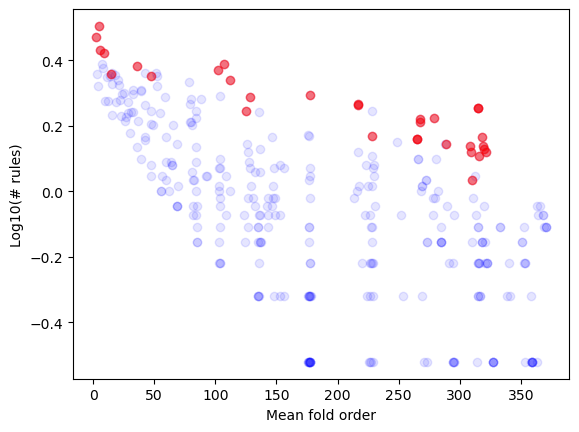

In [189]:
fig, ax = plt.subplots()

dict1 = feature1
dict2 = target

# dict3 = {k:v for k,v in feature1.items() if k in outlier_keys2 and x2rulesNum_run[k] > 3}  # above plane
dict3 = {k:v for k,v in feature1.items() if k in outlier_keys and x2rulesNum_run[k] > 3}  # 1.5*std

valid_keys, data1, data2 = todata(dict1, dict2)
valid_keys, data3, data4 = todata(dict3, dict2)

data2 = np.log10(data2)
data4 = np.log10(data4)

plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
plt.scatter(data3, data4, marker='o', color='r', alpha = 0.5, label='Data Points', zorder=2)
plt.xlabel('Mean fold order')
plt.ylabel('Log10(# rules)')
plt.show()

In [192]:
# for m in x2modules['3323']:
#     print(m, module2name[m])

# # fatty acid biosynthesis... specialized metabolism? recursive chemistry => many rns?

In [193]:
# for rn in x2rn['3323']:
#     print(rn, [cpd2name[c] for c in rn2cpds[rn]])

In [214]:
mods = []
for x in dict3.keys():
    for m in x2modules.get(x, []):
        mods.append(m)

mods_dict = dict(Counter(mods))
sorted_dict = dict(sorted(mods_dict.items(), key=lambda item: item[1], reverse=True))

for k,v in sorted_dict.items():
    print(v, k, module2name[k])

11 M00082 Fatty acid biosynthesis, initiation
10 M00375 Hydroxypropionate-hydroxybutylate cycle
10 M00083 Fatty acid biosynthesis, elongation
8 M00376 3-Hydroxypropionate bi-cycle
8 M00838 Undecylprodigiosin biosynthesis, L-proline => undecylprodigiosin
7 M00113 Jasmonic acid biosynthesis
7 M00374 Dicarboxylate-hydroxybutyrate cycle
7 M00357 Methanogenesis, acetate => methane
7 M00104 Bile acid biosynthesis, cholesterol => cholate/chenodeoxycholate
7 M00545 Trans-cinnamate degradation, trans-cinnamate => acetyl-CoA
7 M00830 Neocarzinostatin naphthoate moiety biosynthesis, malonyl-CoA => 2-hydroxy-5-methyl-1-naphthoate => 2-hydroxy-7-methoxy-5-methyl-1-naphthoyl-CoA
6 M00121 Heme biosynthesis, plants and bacteria, glutamate => heme
6 M00373 Ethylmalonyl pathway
6 M00932 Phylloquinone biosynthesis, chorismate (+ phytyl-PP) => phylloquinol
6 M00740 Methylaspartate cycle
6 M00009 Citrate cycle (TCA cycle, Krebs cycle)
6 M00116 Menaquinone biosynthesis, chorismate (+ polyprenyl-PP) => menaq

## test difference between 'evolvable' folds vs. others – for MANY features

In [55]:
x2O2rnFrac = csv2dict("../data/assets/xgroup2/xgroup2O2rnFrac.csv")
x2indepRuleFrac = csv2dict("../data/assets/xgroup2/xgroup2indepRulesFraction.csv")

r_path = '../data/assets/xgroup2/xgroup2repetitiveness_v1.json'
fc_path = '../data/assets/xgroup2/xgroup2fgroup_count_v1.json'
theme_path = '../data/assets/xgroup2/xgroup2theme_connections_v1.json'
co_path = '../data/assets/xgroup2/xgroup2contact_order_v1.json'

with open(fc_path, 'r') as file:
    x2fc = json.load(file)
with open(theme_path, 'r') as file:
    x2theme = json.load(file)
with open(r_path, 'r') as file:
    x2rep = json.load(file)
with open(co_path, 'r') as file:
    x2co_0 = json.load(file)

x2co = {k:v['MEAN'] for k,v in x2co_0.items()}

In [195]:
evo = list(dict3.keys())
n_evo = [x for x,v in x2foMean.items() if x not in evo]
# n_evo = [x for x,v in x2foMean.items() if x not in evo and v > 100]  # also make sure it's after 100 iterations
len(evo), len(n_evo)

(32, 364)

In [57]:
# u-test for numerical data
def utest(quantity, dict, set1, set2):
    data1 = [v for k,v in dict.items() if k in set1]
    data2 = [v for k,v in dict.items() if k in set2]
    statistic, p_value = mannwhitneyu(data1, data2)
    print(quantity, format(p_value, ".2e"), (round(np.mean(data1), 3), round(np.mean(data2),3)))

# chi^2 for categorical data
def chitest(quantity, dict, set1, set2):
    data1 = [v for k,v in dict.items() if k in set1]
    data2 = [v for k,v in dict.items() if k in set2]
    
    # Count frequencies of values in both sets
    freq1 = Counter(data1)
    freq2 = Counter(data2)
    
    # Create a list of all unique values across both sets
    all_values = list(set(freq1.keys()).union(set(freq2.keys())))
    
    # Build contingency table with counts of each value
    contingency_table = [
        [freq1.get(val, 0) for val in all_values],  # Counts for set1
        [freq2.get(val, 0) for val in all_values]   # Counts for set2
    ]
    
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
    print(quantity, format(p_value, ".2e"))

In [196]:
utest('ds:', x2ds, evo, n_evo), utest('fo:',x2foMean, evo, n_evo), utest('#rules:', x2rulesNum_run, evo, n_evo)

ds: 6.25e-01 (0.395, 0.422)
fo: 9.37e-01 (197.391, 195.663)
#rules: 5.73e-14 (177.438, 20.308)


(None, None, None)

In [197]:
utest('O2rnFrac:', x2O2rnFrac, evo, n_evo), utest('indepRuleFrac:', x2indepRuleFrac, evo, n_evo)

O2rnFrac: 5.97e-04 (0.192, 0.122)
indepRuleFrac: 4.64e-01 (0.183, 0.297)


(None, None)

In [198]:
utest('f-count', x2fc, evo, n_evo), utest('contact_order', x2co, evo, n_evo), utest('theme', x2theme, evo, n_evo), utest('rep', x2rep, evo, n_evo),

f-count 6.32e-03 (70.25, 22.615)
contact_order 5.50e-01 (0.168, 0.177)
theme 2.56e-01 (0.5, 0.212)
rep 7.29e-01 (0.166, 0.159)


(None, None, None, None)

In [199]:
chitest('arc', x2arc, evo, n_evo), chitest('class', x2class, evo, n_evo)

arc 7.26e-01
class 7.04e-01


(None, None)

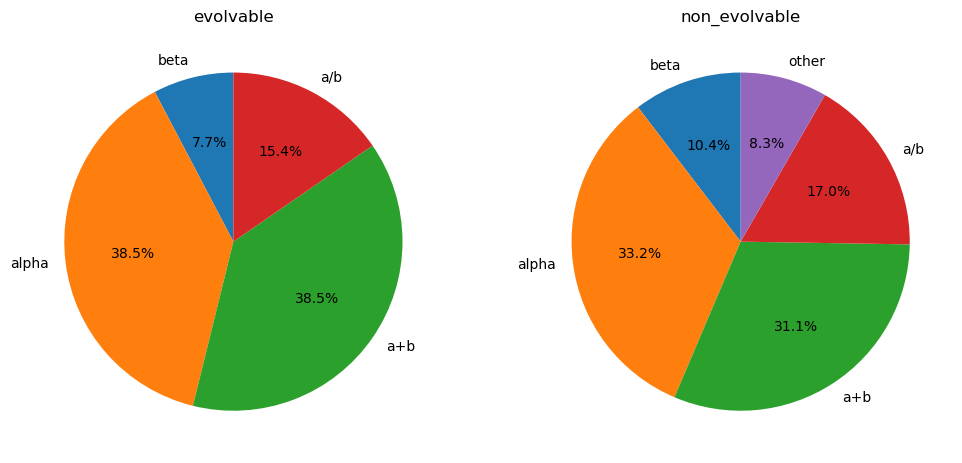

In [62]:
def plot_pie_charts(data_dict, set1, set2, title1, title2):
    # Extract values for the two sets
    data1 = [v for k, v in data_dict.items() if k in set1]
    data2 = [v for k, v in data_dict.items() if k in set2]
    
    # Count frequencies of values in both sets
    freq1 = Counter(data1)
    freq2 = Counter(data2)
    
    # Get labels and frequencies for Set 1
    labels1, sizes1 = zip(*freq1.items())
    # Get labels and frequencies for Set 2
    labels2, sizes2 = zip(*freq2.items())
    
    # Plot pie chart for Set 1
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.pie(sizes1, labels=labels1, autopct='%1.1f%%', startangle=90)
    plt.title(title1)
    
    # Plot pie chart for Set 2
    plt.subplot(1, 2, 2)
    plt.pie(sizes2, labels=labels2, autopct='%1.1f%%', startangle=90)
    plt.title(title2)
    
    plt.show()

plot_pie_charts(x2class, evo, n_evo, 'evolvable', 'non_evolvable')


# 3. EC number for evolvability: 3D regression

In [96]:
rn2ec = csv2dict('../data/assets/rn2ec.csv')

In [105]:
x2rn_run = {}
for x, rns in x2rn.items():
    rns_run = [rn for rn in rns if rn in df_rns_folditer.index]
    x2rn_run[x] = rns_run

In [109]:
for k,v in x2rn_run.items():
    print(k, len(v), len(x2rn[k]))

102 16 36
3086 2 2
4022 1 1
3579 2 2
5100 8 8
2005 63 82
285 1 1
2010 5 13
4952 6 14
4295 1 1
221 131 209
611 2 2
4110 2 4
7528 11 13
868 8 9
301 57 64
184 10 13
7553 3 3
1077 2 2
7556 4 4
4017 6 6
313 2 2
4019 7 9
3687 10 14
325 98 129
6096 1 1
7549 3 3
177 4 5
7601 1 1
3257 3 3
4028 2 2
131 37 49
199 2 2
7536 3 3
3651 2 2
258 2 4
4035 6 6
214 7 11
7512 125 298
867 12 12
10 211 348
3978 4 7
243 90 158
1137 15 23
6051 2 2
3323 52 52
7539 3 3
323 68 112
4018 18 18
107 23 30
7561 15 16
2487 82 92
3016 178 204
7602 1 1
309 1 1
3001 1 1
146 22 25
2003 1380 1923
387 2 5
282 8 8
283 5 5
4178 9 9
2002 789 1025
7523 11 13
144 1 1
6166 5 7
328 10 12
244 217 301
4159 2 4
217 90 116
5084 10 23
7546 4 5
3500 2 3
3599 2 2
4076 1 1
7517 8 10
3304 2 3
3994 1 1
3371 5 5
7580 4 4
806 4 4
842 1 1
236 135 191
279 50 54
4054 6 6
1144 1 1
650 1 1
528 1 3
3752 1 1
3654 2 2
3321 52 52
241 1 1
3754 5 7
262 15 15
3686 11 13
7516 75 142
623 4 4
5 74 130
7513 3 3
232 9 10
3858 10 10
286 10 10
2011 49 67
4049 6 6

In [112]:
x2rn_ec1 = {}
x2rn_ec2 = {}
x2rn_ec3 = {}
for x, rns in x2rn_run.items():
    ec_list1 = []
    ec_list2 = []
    ec_list3 = []
    for rn in rns:
        if rn2ec.get(rn[:6], 0) == 0:  # ignore reactions with no EC annotation
            continue
        else:
            ec_list1.append(rn2ec[rn[:6]].split('.')[0])
            ec_list2.append(rn2ec[rn[:6]].split('.')[0] + '.' + rn2ec[rn[:6]].split('.')[1])
            ec_list3.append(rn2ec[rn[:6]].split('.')[0] + '.' + rn2ec[rn[:6]].split('.')[1] + '.' + rn2ec[rn[:6]].split('.')[2])
    x2rn_ec1[x] = set(ec_list1)
    x2rn_ec2[x] = set(ec_list2)
    x2rn_ec3[x] = set(ec_list3)

In [113]:
x2numEC1 = {k:len(v) for k,v in x2rn_ec1.items()}
x2numEC2 = {k:len(v) for k,v in x2rn_ec2.items()}
x2numEC3 = {k:len(v) for k,v in x2rn_ec3.items()}

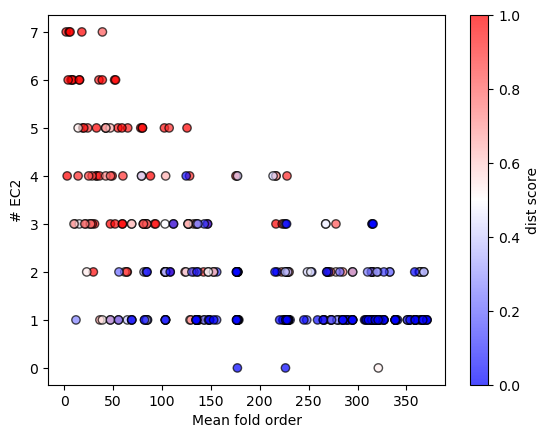

In [123]:
scatterColor(x2foMean, x2numEC1, x2ds_run, 'Mean fold order', '# EC2', 'dist score') 

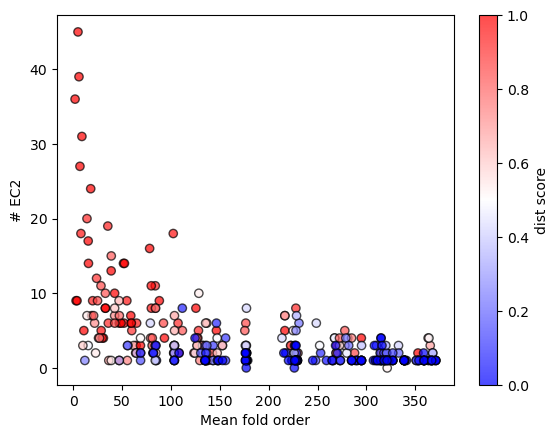

/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_68992/2494560972.py:8: RuntimeWarning:

divide by zero encountered in log10



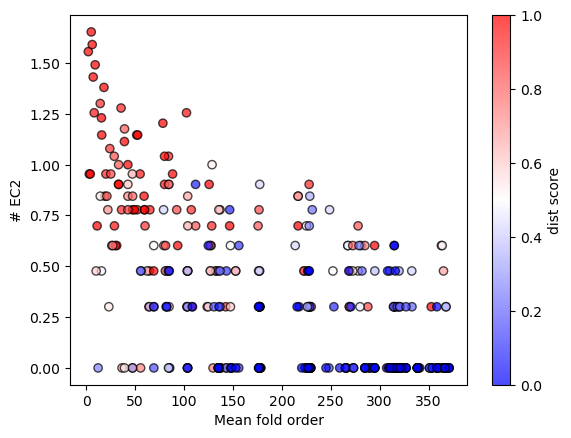

In [121]:
scatterColor(x2foMean, x2numEC2, x2ds_run, 'Mean fold order', '# EC2', 'dist score') 
scatterColor(x2foMean, x2numEC2, x2ds_run, 'Mean fold order', '# EC2', 'dist score', ylog=True) 

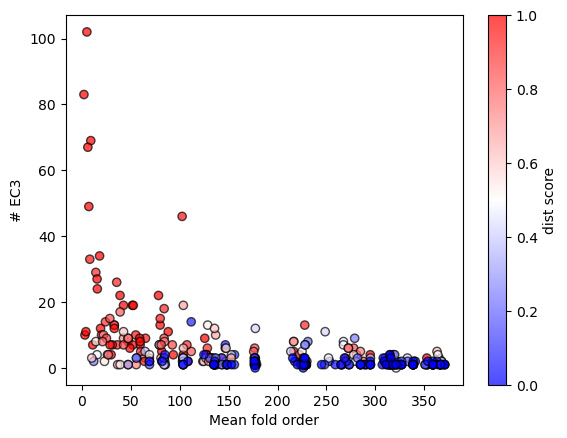

/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_68992/2494560972.py:8: RuntimeWarning:

divide by zero encountered in log10



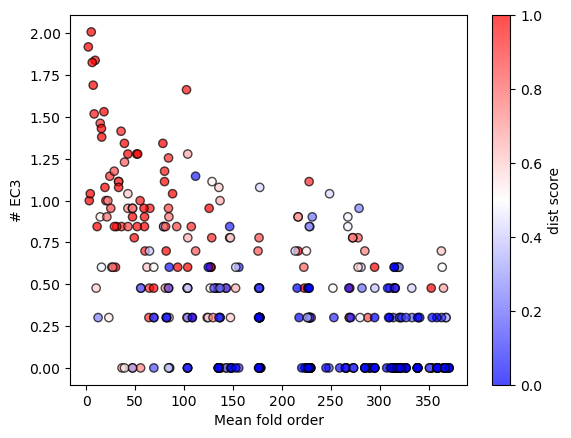

In [120]:
scatterColor(x2foMean, x2numEC3, x2ds_run, 'Mean fold order', '# EC3', 'dist score') 
scatterColor(x2foMean, x2numEC3, x2ds_run, 'Mean fold order', '# EC3', 'dist score', ylog=True) 

In [209]:
# 3D regression with x2numEC3, x2foMean, x2ds

# target = x2rulesNum_run  # target (dependent);
target = {k:np.log10(v) for k,v in x2numEC3.items() if not v == 0}  # target (dependent); log10, remove 0's
feature1 = {k:v for k,v in x2foMean.items() if k in target}  # feature (independent)
feature2 = {k:v for k,v in x2ds_run.items() if k in target}  # feature (independent)

# Ensure consistent ordering of keys
keys = list(target.keys())

# Extract feature and target values in the same order
X = np.array([[feature1[k], feature2[k]] for k in keys])  # 2D array of features
y = np.array([target[k] for k in keys])  # Target variable

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Print the coefficients and intercept
print("Coefficients (slopes):", model.coef_)
print("Intercept:", model.intercept_)

Coefficients (slopes): [-0.00126869  0.56874095]
Intercept: 0.3981892972036426


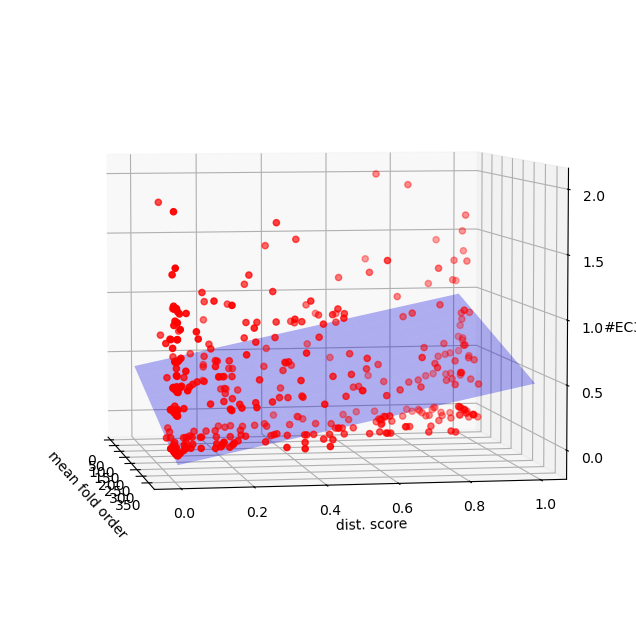

In [211]:
# static plot

# Coefficients and intercept
coef = model.coef_
intercept = model.intercept_

# Generate points on the regression plane for visualization
feature1_vals = np.linspace(min(feature1.values()), max(feature1.values()), 10)
feature2_vals = np.linspace(min(feature2.values()), max(feature2.values()), 10)
feature1_vals, feature2_vals = np.meshgrid(feature1_vals, feature2_vals)
target_vals = coef[0] * feature1_vals + coef[1] * feature2_vals + intercept

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the original data points
ax.scatter(list(feature1.values()), list(feature2.values()), list(target.values()), color='red', label='Data Points')

# Plot the regression plane
ax.plot_surface(feature1_vals, feature2_vals, target_vals, color='blue', alpha=0.3)

# Set labels
ax.set_xlabel('mean fold order')
ax.set_ylabel('dist. score')
ax.set_zlabel('#EC3')

# Adjust the 3D perspective (e.g., 30° elevation, 60° azimuth)
ax.view_init(elev=5, azim=350)

# Show plot
plt.show()

In [218]:
# Define the outliers (mean & std of residuals)

# Calculate predicted values
y_pred = model.predict(X)

# Calculate residuals (actual - predicted)
residuals = y - y_pred

# Calculate the mean and standard deviation of the residuals
mean_residual = np.mean(residuals)
std_residual = np.std(residuals)

# Define a threshold for outliers (e.g., residuals greater than X standard deviations from the mean)
threshold = 1.5 * std_residual

# Identify index of outliers
outliers = np.where((np.abs(residuals - mean_residual) > threshold) & (residuals > 0))[0]  # make sure it's positive

# Print the outliers
keys = list(target.keys()) 
outlier_keys = [keys[i] for i in outliers]  # convert index to key
print("Outlier keys:", outlier_keys)
print("Outlier residuals:", residuals[outliers])

Outlier keys: ['221', '10', '243', '3323', '107', '146', '2003', '2002', '244', '217', '3321', '11', '108', '5069', '4294', '2004', '304', '3322', '149', '1', '3740', '179', '4052', '66', '1001', '2007', '231', '101', '7514', '4033', '109', '633']
Outlier residuals: [0.48402184 0.58197828 0.66693925 0.60224766 0.58998797 0.46753609
 1.04801316 0.95468502 0.84369033 0.62557267 0.603133   0.55936323
 0.58976189 0.54175145 0.49047993 0.58738483 0.88333682 0.47979755
 0.85032989 0.73214644 0.66926825 0.76988894 0.57739468 0.52354071
 0.71818118 0.86675647 0.50837954 0.47480501 0.57554321 0.51851196
 0.5289935  0.47879977]


In [219]:
len(target), len(outliers)

(393, 32)

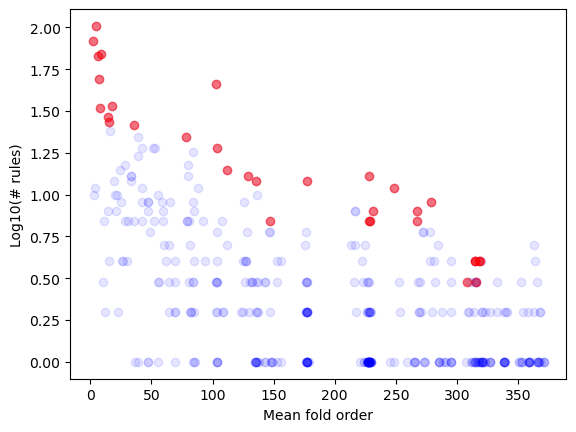

In [220]:
fig, ax = plt.subplots()

dict1 = feature1
dict2 = target

# dict3 = {k:v for k,v in feature1.items() if k in outlier_keys2 and x2rulesNum_run[k] > 3}  # above plane
dict3 = {k:v for k,v in feature1.items() if k in outlier_keys and x2rulesNum_run[k] > 3}  # 1.5*std

valid_keys, data1, data2 = todata(dict1, dict2)
valid_keys, data3, data4 = todata(dict3, dict2)

# data2 = np.log10(data2)
# data4 = np.log10(data4)

plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
plt.scatter(data3, data4, marker='o', color='r', alpha = 0.5, label='Data Points', zorder=2)
plt.xlabel('Mean fold order')
plt.ylabel('Log10(# rules)')
plt.show()

In [221]:
mods = []
for x in dict3.keys():
    for m in x2modules.get(x, []):
        mods.append(m)

mods_dict = dict(Counter(mods))
sorted_dict = dict(sorted(mods_dict.items(), key=lambda item: item[1], reverse=True))

for k,v in sorted_dict.items():
    print(v, k, module2name[k])

11 M00531 Assimilatory nitrate reduction, nitrate => ammonia
10 M00009 Citrate cycle (TCA cycle, Krebs cycle)
9 M00356 Methanogenesis, methanol => methane
9 M00374 Dicarboxylate-hydroxybutyrate cycle
9 M00357 Methanogenesis, acetate => methane
9 M00563 Methanogenesis, methylamine/dimethylamine/trimethylamine => methane
9 M00567 Methanogenesis, CO2 => methane
9 M00779 Dihydrokalafungin biosynthesis, octaketide => dihydrokalafungin
8 M00377 Reductive acetyl-CoA pathway (Wood-Ljungdahl pathway)
8 M00375 Hydroxypropionate-hydroxybutylate cycle
8 M00546 Purine degradation, xanthine => urea
8 M00532 Photorespiration
8 M00534 Naphthalene degradation, naphthalene => salicylate
8 M00545 Trans-cinnamate degradation, trans-cinnamate => acetyl-CoA
8 M00011 Citrate cycle, second carbon oxidation, 2-oxoglutarate => oxaloacetate
8 M00637 Anthranilate degradation, anthranilate => catechol
7 M00113 Jasmonic acid biosynthesis
7 M00376 3-Hydroxypropionate bi-cycle
7 M00173 Reductive citrate cycle (Arnon-

In [225]:
evo = list(dict3.keys())
n_evo = [x for x,v in x2foMean.items() if x not in evo]
# n_evo = [x for x,v in x2foMean.items() if x not in evo and v > 100]  # also make sure it's after 100 iterations
len(evo), len(n_evo)

(32, 364)

In [226]:
utest('O2rnFrac:', x2O2rnFrac, evo, n_evo), utest('indepRuleFrac:', x2indepRuleFrac, evo, n_evo)

O2rnFrac: 6.86e-09 (0.214, 0.12)
indepRuleFrac: 6.29e-01 (0.21, 0.295)


(None, None)

In [227]:
utest('f-count', x2fc, evo, n_evo), utest('contact_order', x2co, evo, n_evo), utest('theme', x2theme, evo, n_evo), utest('rep', x2rep, evo, n_evo),

f-count 5.32e-06 (150.969, 15.519)
contact_order 4.47e-01 (0.183, 0.175)
theme 7.83e-08 (1.219, 0.148)
rep 5.72e-02 (0.211, 0.153)


(None, None, None, None)

In [228]:
chitest('arc', x2arc, evo, n_evo), chitest('class', x2class, evo, n_evo)

arc 2.41e-01
class 4.94e-01


(None, None)